# YOLOv8 Food Detection - Training with NewDataset
This notebook will:
1. Mount your Google Drive.
2. Prepare paths for `NewDataset` (already in YOLO format).
3. Update `data.yaml` to ensure paths are correct for Colab.
4. Train the YOLOv8 model, saving checkpoints to Google Drive.
5. Evaluate and Export the final model.

In [ ]:
# 1. Install Dependencies
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [1]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import yaml

# 3. Paths Definition
drive_path = '/content/drive/MyDrive/food-dataset'
dataset_path = os.path.join(drive_path, 'NewDataset')
yaml_path = os.path.join(dataset_path, 'data.yaml')
yolo_runs_path = os.path.join(drive_path, 'runs')

print(f"Dataset Path: {dataset_path}")
print(f"YAML Path: {yaml_path}")

# Update data.yaml with absolute paths to avoid path resolution issues in Colab
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)

    data['train'] = os.path.join(dataset_path, 'train/images')
    data['val'] = os.path.join(dataset_path, 'valid/images')
    if 'test' in data:
        data['test'] = os.path.join(dataset_path, 'test/images')

    with open(yaml_path, 'w') as f:
        yaml.dump(data, f, sort_keys=False)
    print("Updated data.yaml with absolute Colab paths:")
    print(yaml.dump(data, sort_keys=False))
else:
    print(f"WARNING: {yaml_path} not found. Ensure dataset is uploaded.")

Dataset Path: /content/drive/MyDrive/food-dataset/NewDataset
YAML Path: /content/drive/MyDrive/food-dataset/NewDataset/data.yaml
Updated data.yaml with absolute Colab paths:
train: /content/drive/MyDrive/food-dataset/NewDataset/train/images
val: /content/drive/MyDrive/food-dataset/NewDataset/valid/images
test: /content/drive/MyDrive/food-dataset/NewDataset/test/images
nc: 13
names:
- Ayam Goreng
- Ayam Goreng Tepung
- Ikan Bandeng Goreng
- Nasi Putih
- Perkedel Jagung
- Sayur Bening Bayam
- Singkong Rebus
- Tahu Goreng
- Telur Dadar
- Telur Rebus
- Tempe Goreng
- Tumis Buncis
- Tumis Kangkung
roboflow:
  workspace: object-detection-iwjvk
  project: food-detections-smnmn
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/object-detection-iwjvk/food-detections-smnmn/dataset/1



In [ ]:
# 3.5 Optional Data Augmentation & Calibration
import random
import shutil
import os

val_images_dir = os.path.join(dataset_path, 'valid/images')
val_labels_dir = os.path.join(dataset_path, 'valid/labels')
train_images_dir = os.path.join(dataset_path, 'train/images')
train_labels_dir = os.path.join(dataset_path, 'train/labels')

if os.path.exists(val_images_dir) and os.path.exists(train_images_dir):
    val_images = os.listdir(val_images_dir)
    # Select 25% for calibration mixing
    sample_size = int(len(val_images) * 0.25)
    selected_images = random.sample(val_images, sample_size)

    for img_name in selected_images:
        # Get matching label
        lbl_name = img_name.rsplit('.', 1)[0] + '.txt'

        # Copy to train
        img_src = os.path.join(val_images_dir, img_name)
        img_dst = os.path.join(train_images_dir, img_name)
        if os.path.exists(img_src):
            shutil.copy(img_src, img_dst)

        lbl_src = os.path.join(val_labels_dir, lbl_name)
        lbl_dst = os.path.join(train_labels_dir, lbl_name)
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, lbl_dst)

    print(f"Data calibration complete: {sample_size} samples mixed.")


Data calibration complete: 26 samples mixed.


In [ ]:
from ultralytics import YOLO
import os

# 4. Initialize YOLOv8 Model (with Resume Capability for v2)
# We check if the NEW v2 checkpoint exists to resume. We DO NOT resume from the old broken v1.
checkpoint_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v2/weights/last.pt')

if os.path.exists(checkpoint_path):
    print("Found v2 checkpoint. Resuming training...")
    model = YOLO(checkpoint_path)
    resume_status = True
else:
    print("No v2 checkpoint found. Starting fresh from yolov8n.pt...")
    model = YOLO('yolov8n.pt')
    resume_status = False


Found v2 checkpoint. Resuming training...


In [ ]:
# 5. Train the Model
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project=yolo_runs_path,
    name='yolov8_food_model_v2', # Menggunakan nama baru agar tidak menimpa yang lama
    exist_ok=True,
    resume=resume_status,
    # Menghapus manual hyperparameter (lr0, optimizer, dll) agar YOLOv8 menggunakan settingan Auto-Optimizer bawaan yang lebih stabil.
)


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_food_

In [ ]:
from ultralytics import YOLO
import os

# 6. Load Best Model and Evaluate
best_weights_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v2/weights/best.pt')
model = YOLO(best_weights_path)

print("Evaluating on validation set...")
metrics = model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    device=0,
    project=yolo_runs_path,
    name='yolov8_food_model_final_eval'
)

print(f"mAP50: {metrics.box.map50:.4f}")


Evaluating on validation set...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.8±2.6 ms, read: 18.8±12.6 MB/s, size: 44.2 KB)
val: Scanning /content/drive/MyDrive/food-dataset/NewDataset/valid/labels.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 39.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.5s
                   all        104        187      0.743      0.833      0.843       0.59
           Ayam Goreng         11         18      0.889      0.778      0.852      0.545
    Ayam Goreng Tepung         18         27      0.718       0.66      0.676      0.423
   Ikan Bandeng Goreng          9         16      0.579      0.688      0.725      0.321
            Nasi Putih          2          2       0.93          1      0.995    

In [ ]:
# 7. Export Model for Web App (ONNX)
export_path = model.export(format='onnx')
print(f"Model exported successfully to: {export_path}")


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 329ms
Prepared 4 packages in 5.91s
Installed 4 packages in 284ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 7.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export succ

In [ ]:
# 5.5 Continue Training (Fine-Tuning)
# Me-load 'best.pt' sebelumnya, lalu melatihnya lagi.
from ultralytics import YOLO
import os

best_weights = os.path.join(yolo_runs_path, 'yolov8_food_model_v2/weights/best.pt')
if os.path.exists(best_weights):
    print("Loading best weights to continue training...")
    fine_tune_model = YOLO(best_weights)

    # Lanjutkan training untuk 50 epoch lagi.
    # Disimpan di folder baru '_finetune' agar tidak menimpa versi sebelumnya.
    fine_tune_model.train(
        data=yaml_path,
        epochs=50,  # Ubah angka ini jika ingin menambah/mengurangi epoch
        imgsz=640,
        batch=16,
        device=0,
        project=yolo_runs_path,
        name='yolov8_food_model_v2_finetune',
        exist_ok=True,
    )
else:
    print("Model utama belum selesai di-train!")


Loading best weights to continue training...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2/weights/best.pt, momentum=0.937, m

In [ ]:
from ultralytics import YOLO
import os

# 6. Load Best Model and Evaluate
best_weights_path = os.path.join(yolo_runs_path, 'yolov8_food_model_v2_finetune/weights/best.pt')
model = YOLO(best_weights_path)

print("Evaluating on validation set...")
metrics = model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    device="cpu",
    project=yolo_runs_path,
    name='yolov8_food_model_final_eval'
)

print(f"mAP50: {metrics.box.map50:.4f}")


Evaluating on validation set...
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 4.5±3.2 ms, read: 0.3±0.3 MB/s, size: 37.1 KB)
val: Scanning /content/drive/MyDrive/food-dataset/NewDataset/valid/labels.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 12.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.8s/it 33.7s
                   all        104        187      0.865      0.864      0.883      0.648
           Ayam Goreng         11         18      0.967      0.889      0.972      0.647
    Ayam Goreng Tepung         18         27      0.856      0.663      0.817       0.52
   Ikan Bandeng Goreng          9         16      0.752      0.688      0.756      0.459
            Nasi Putih          2          2          1      0.919      0.995    

In [ ]:
from ultralytics import YOLO

# Load model dari proses yang terhenti tadi (ganti path-nya jika perlu)
model = YOLO('/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2_finetune/weights/last.pt')

# Kita TIDAK pakai resume=True, melainkan memulai sesi baru dengan bobot tersebut
# Set epochs=7 (2 epoch sisa dari target awal + 5 epoch tambahan yang kamu minta)
model.train(
    data='/content/drive/MyDrive/food-dataset/NewDataset/data.yaml',
    epochs=7,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/food-dataset/runs',
    name='yolov8_food_model_v2_extra_5',
    exist_ok=True
)


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2_finetune/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

In [ ]:
 from ultralytics import YOLO

# Load model dari epoch 48 (pastikan path-nya sesuai dengan letak file last.pt terakhir kamu)
model = YOLO('/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2_finetune/weights/best.pt')

# Fine-Tuning dengan Penyesuaian Hyperparameter
model.train(
    data='/content/drive/MyDrive/food-dataset/NewDataset/data.yaml',
    epochs=10,            # Diberi 10 epoch karena pergerakan learning ratenya sekarang sangat halus
    imgsz=640,
    batch=16,
    device=0,
    project='/content/drive/MyDrive/food-dataset/runs',
    name='yolov8_food_model_v2_finetune_hyper',
    exist_ok=True,

    # --- HYPERPARAMETER TUNING ---
    lr0=0.0001,           # Learning rate sangat kecil agar tidak merusak model
    lrf=0.01,             # Final learning rate
    warmup_epochs=0.0,    # Langsung train tanpa warmup
    momentum=0.937,       # Mempertahankan arah gradien
    weight_decay=0.0005,  # Mencegah model menghafal jawaban (overfitting)
    mosaic=0.0,           # Matikan gambar terpotong agar model fokus ke makanan utuh
    close_mosaic=0,
    optimizer='SGD'       # SGD lebih halus untuk fine-tuning
)


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/food-dataset/NewDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2_finetune/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79545409f500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [ ]:
# Print map50 and map50-95 fields specifically
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

# Get precision and recall for all classes
precision_per_class = metrics.box.p # Returns an array of precision values
recall_per_class = metrics.box.r    # Returns an array of recall values

# Example: Display precision for each class nicely
for class_id, score in enumerate(precision_per_class):
    print(f"Class {class_id} Precision: {score:.4f}")

NameError: name 'metrics' is not defined

--- Displaying: results.png ---


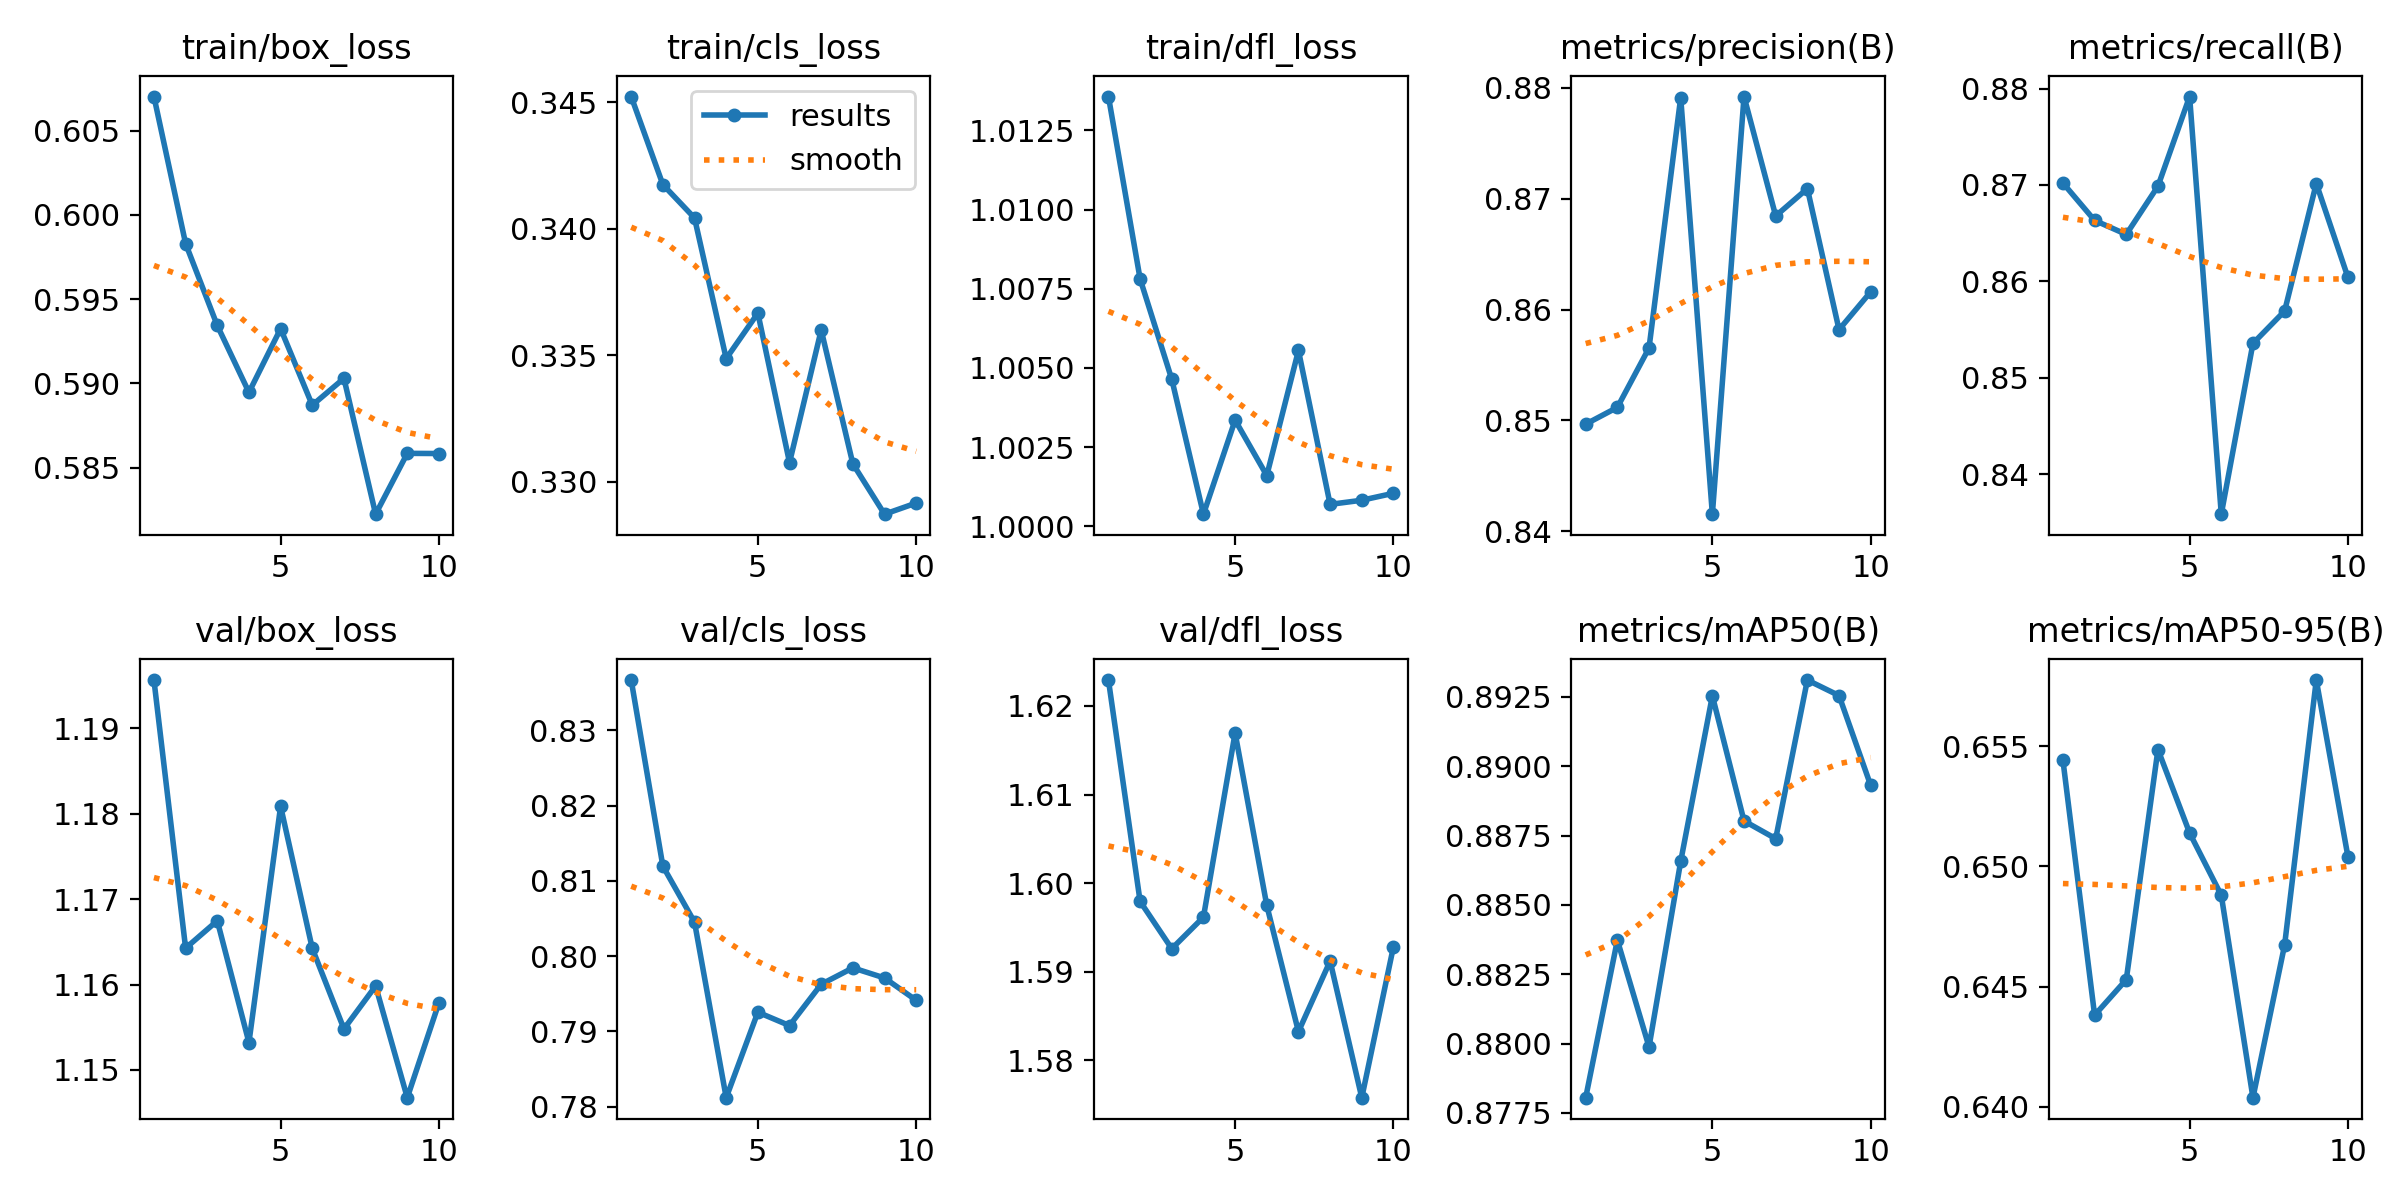

--- Displaying: confusion_matrix_normalized.png ---


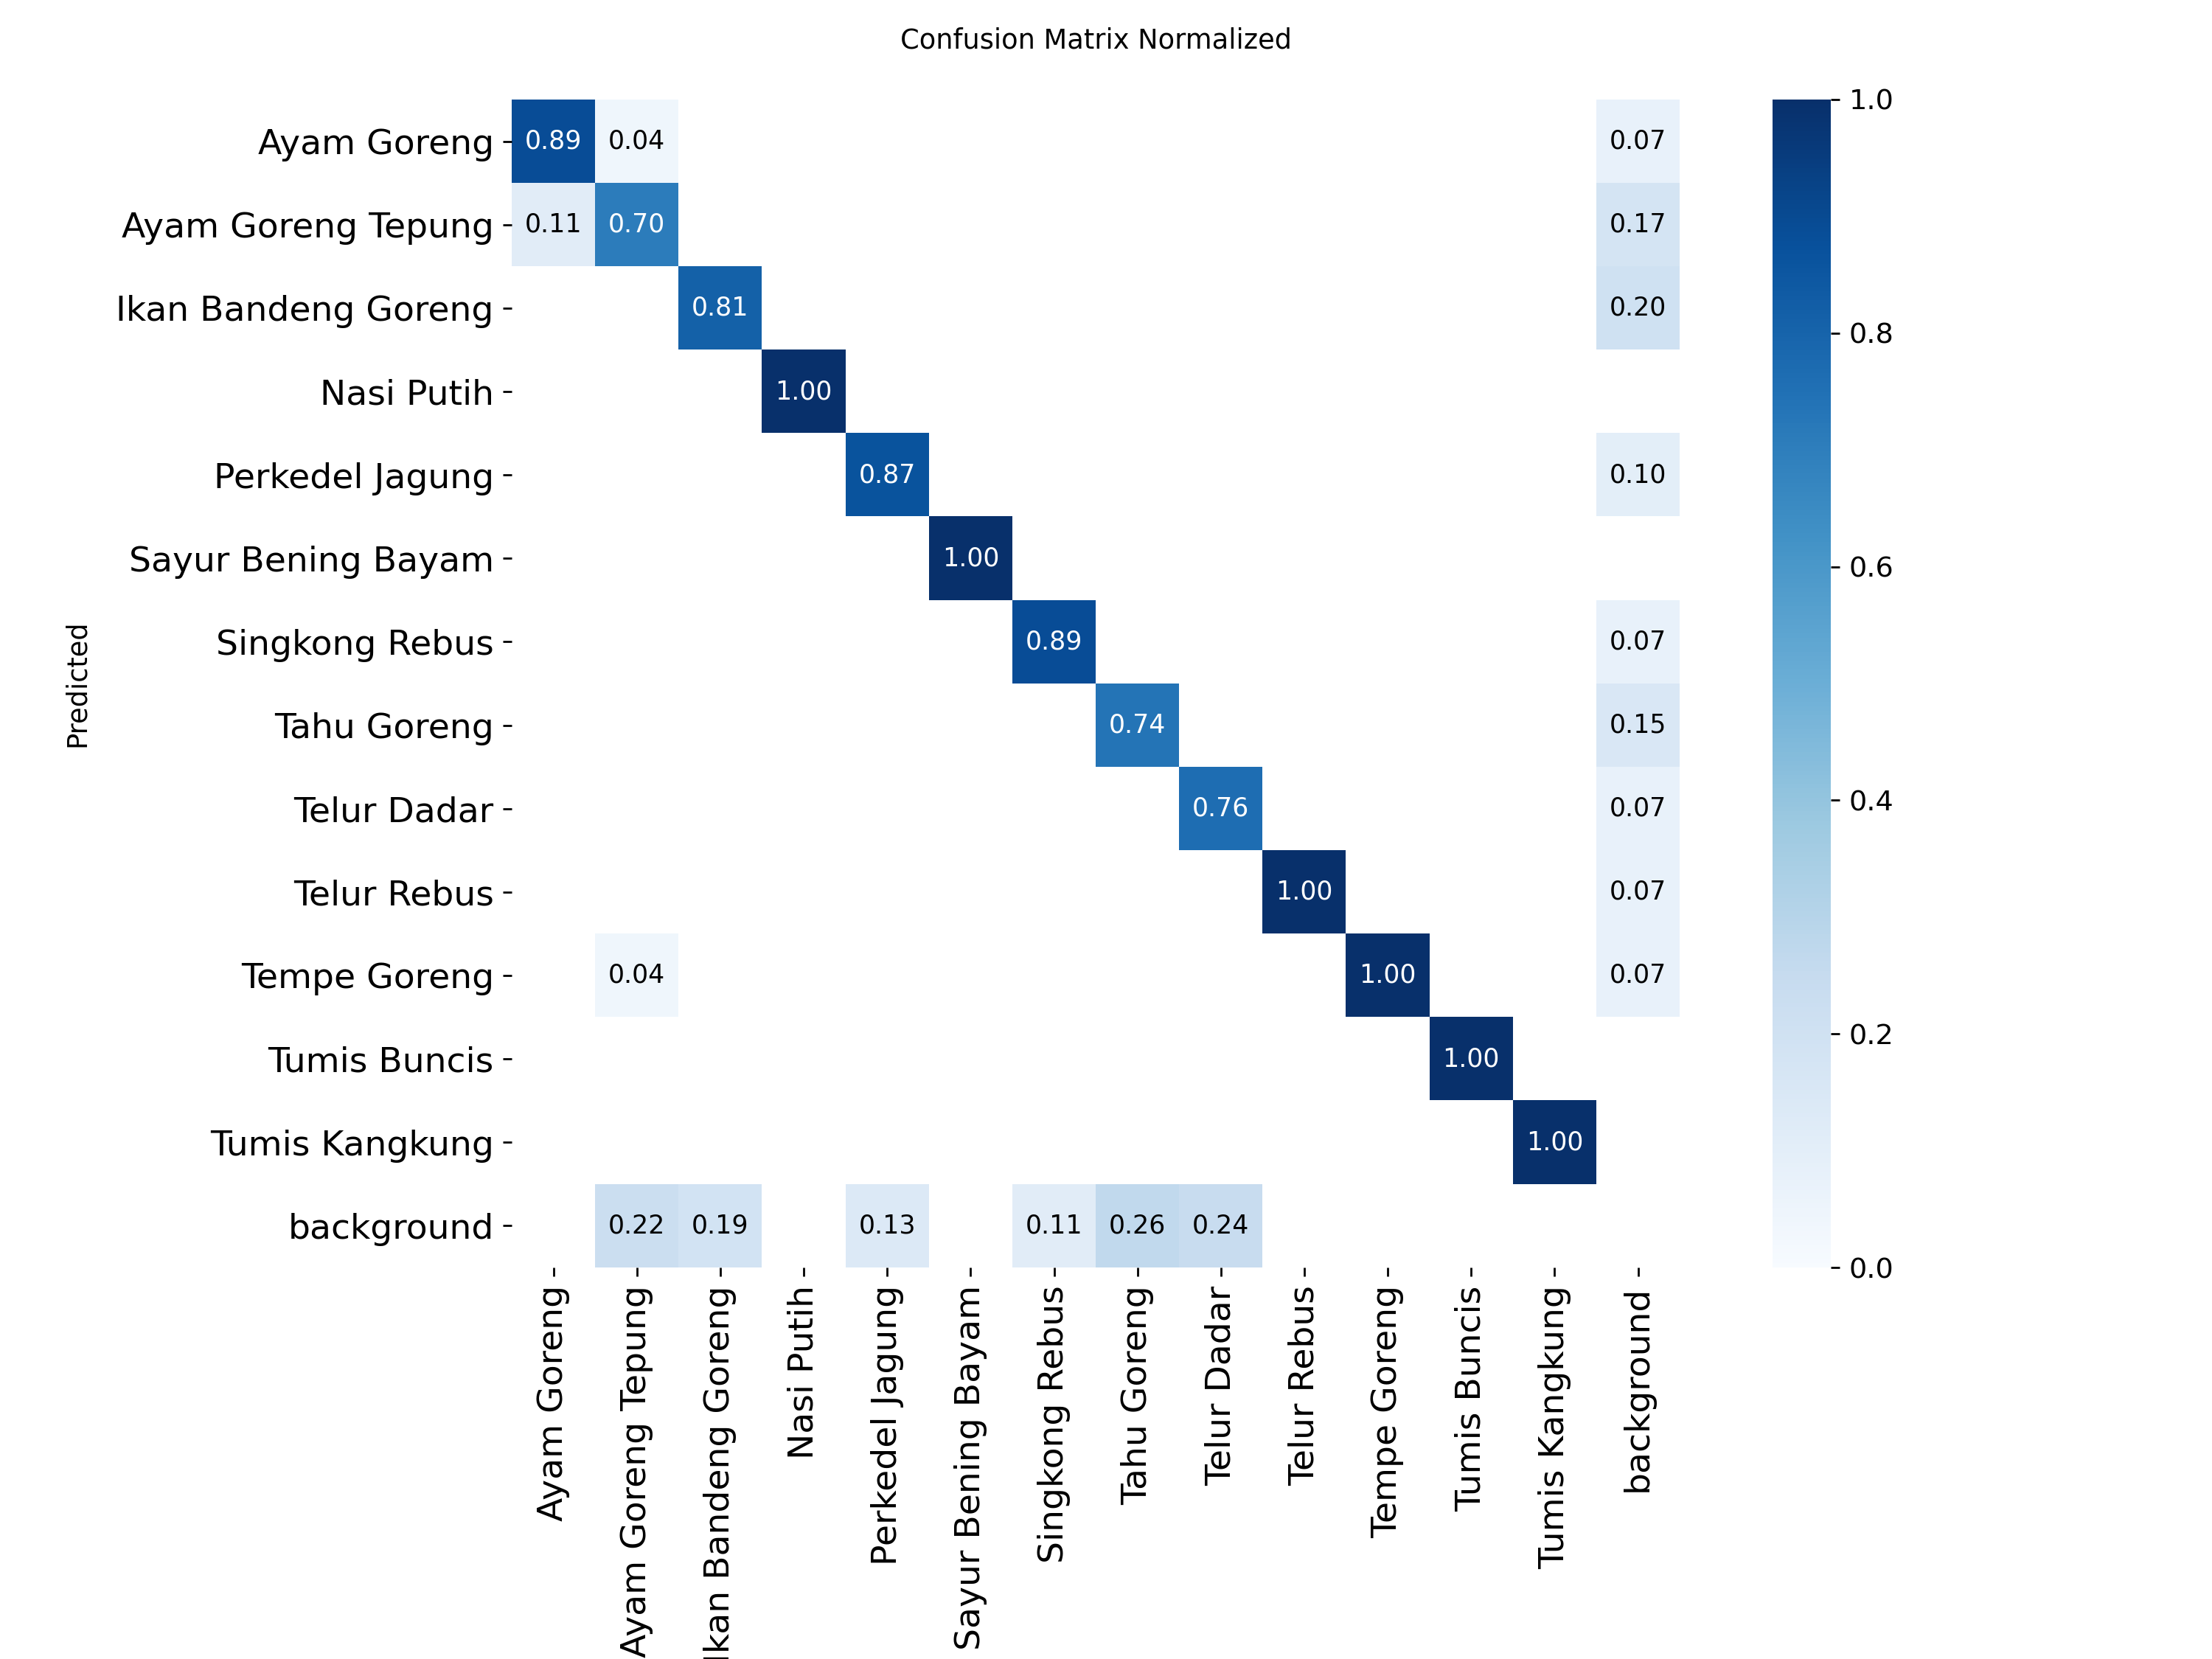

--- Displaying: BoxF1_curve.png ---


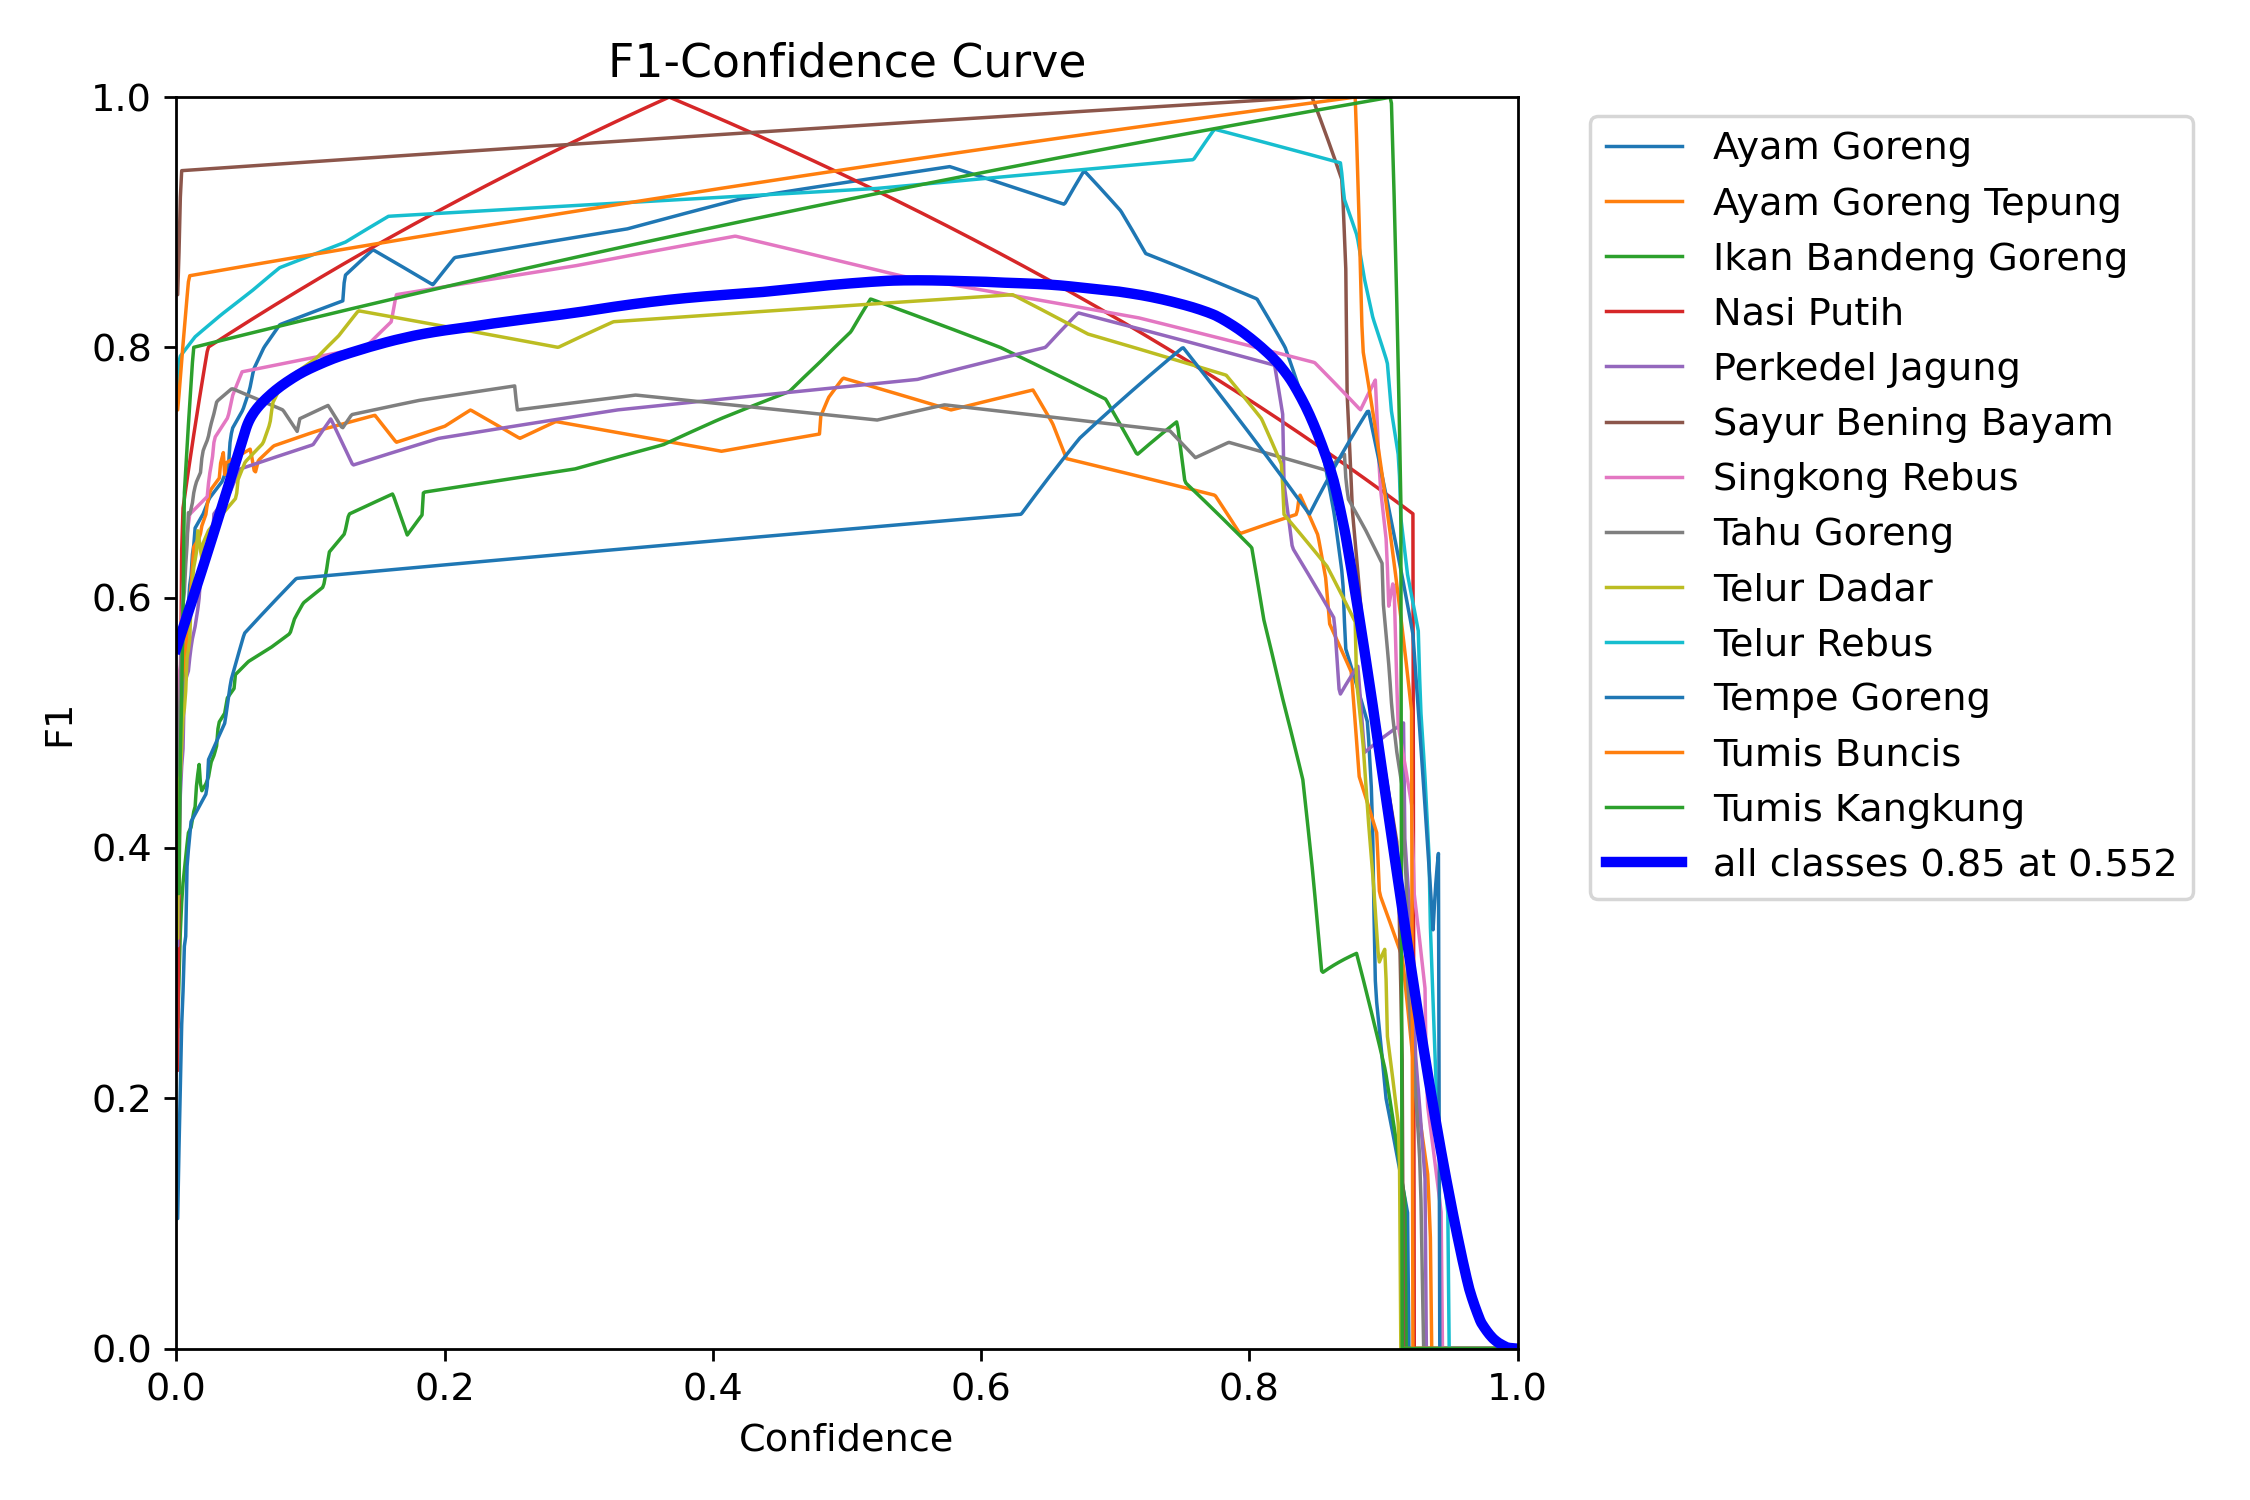

--- Displaying: BoxPR_curve.png ---


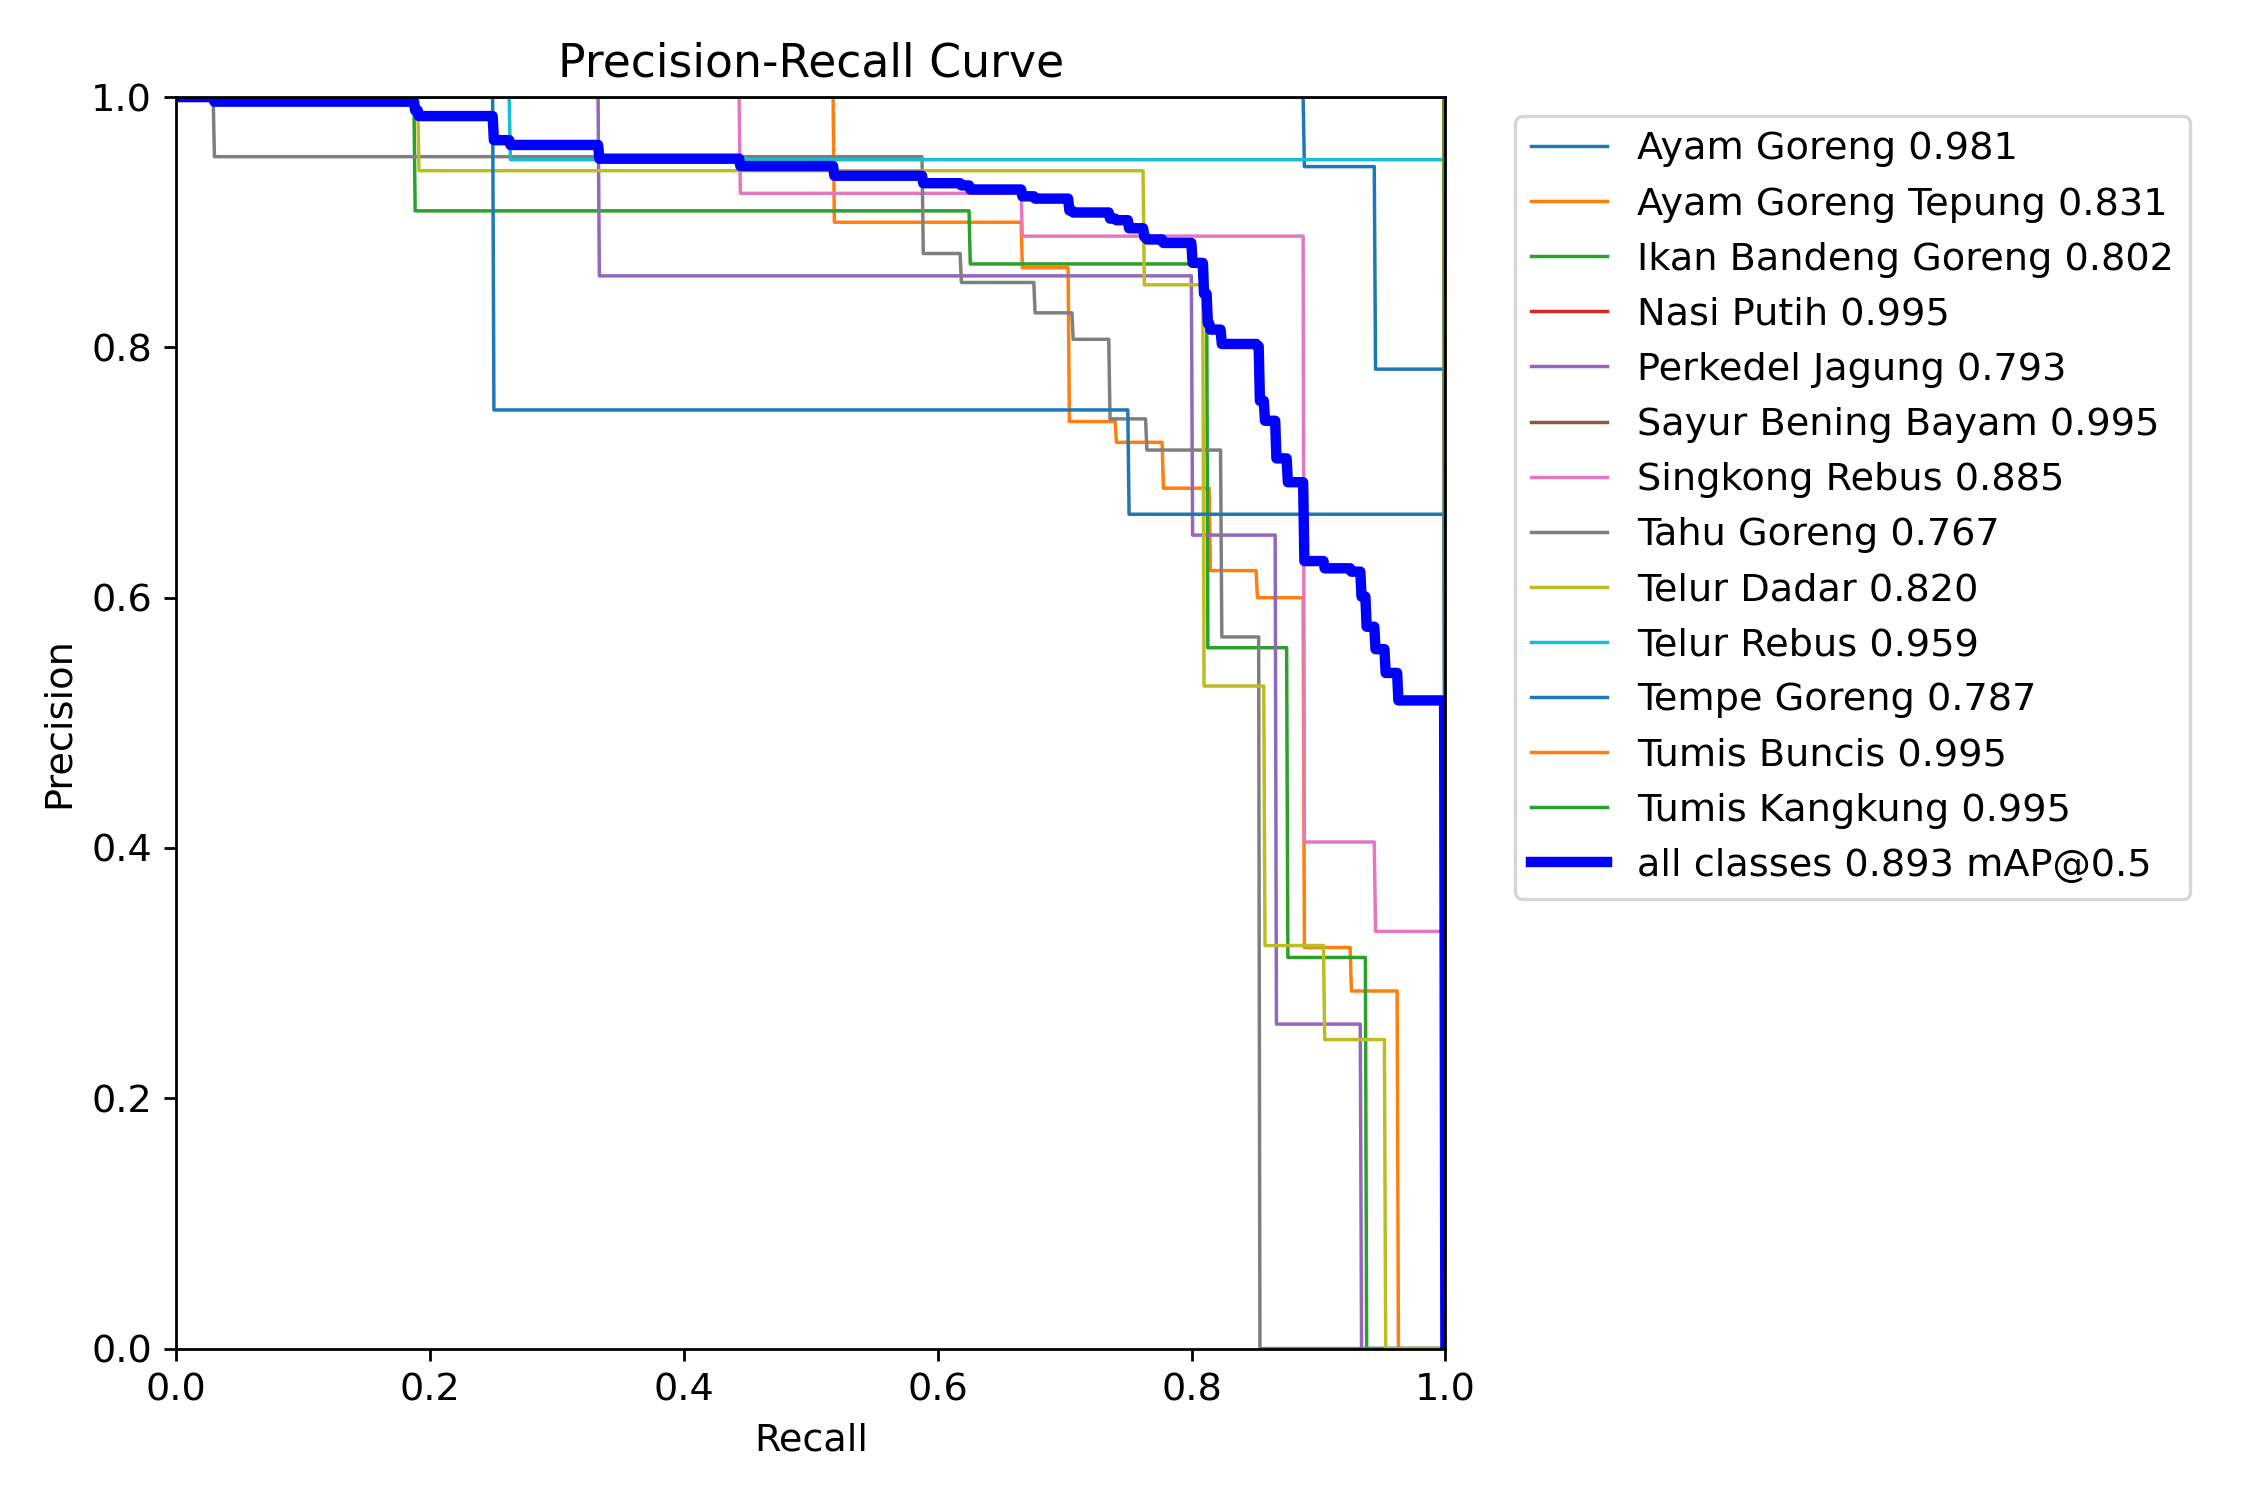

In [2]:
import os
from IPython.display import Image, display

# Define the directory where the training results are saved
# Make sure this matches the project + name defined in model.train()
save_dir = '/content/drive/MyDrive/food-dataset/runs/yolov8_food_model_v2_finetune_hyper'

# List of important evaluation plots to display
plots_to_show = [
    'results.png',
    'confusion_matrix_normalized.png',
    'BoxF1_curve.png',
    'BoxPR_curve.png'
]

# Loop through and display each file if it exists
for plot in plots_to_show:
    full_path = os.path.join(save_dir, plot)
    if os.path.exists(full_path):
        print(f"--- Displaying: {plot} ---")
        display(Image(filename=full_path, width=700))
    else:
        print(f"File not found: {plot}")